## 实现铰接模式
### Plan A 
### 采用原始模型建立铰接模式的计算模型
### 采用全矩阵的方式，不引入降维思想

In [7]:
#import packages
import time
import numpy as np
import capytaine as cpt
import scipy
from capytaine.io.mesh_writers import write_STL
import matplotlib.pyplot as plt
from scipy.linalg import block_diag
from scipy.linalg import eigh
import vtk
import logging
import xarray as xr
from capytaine.io.xarray import merge_complex_values
from capytaine.post_pro import rao
logging.basicConfig(level=logging.INFO, format='%(levelname)-8s: %(message)s')
# user defined functions
import DM_ShowNodes as DMshow
import DM_Reading as dm_r
import DM_Assemble as DM_A
import SEREP as SEREP

### 经典水弹性计算波浪问题

In [8]:
# 原方法
def calculate_displacement(N, K_structure, dataset, nodes):
    """
    Calculate the displacement for a given system of order method.

    Parameters:
    N (int): The number of nodes in the system.
    file_path (str): Path to the stiffness matrix file.
    dataset (DataFrame): A pandas DataFrame containing the necessary data.
    nodes (array): Array of node positions.

    Returns:
    ndarray: The displacement array.
    """

    # Extract data from the dataset
    added_mass = dataset['added_mass'][0].values
    radiation_damping = dataset['radiation_damping'][0].values
    inertia_matrix = dataset['inertia_matrix'].values
    hydrostatic_stiffness = dataset['hydrostatic_stiffness'].values
    F_w = dataset['Froude_Krylov_force'][0].values + dataset['diffraction_force'][0].values

    # Construct the combined matrices
    M = added_mass + inertia_matrix  # Total mass
    C = radiation_damping  # Damping
    K = hydrostatic_stiffness  # Stiffness

    # Insert matrices into the system
    mass = DM_A.insert_matrix(N, M, nodes)
    damping = DM_A.insert_matrix(N, C, nodes)
    hy_stiffness = DM_A.insert_matrix(N, K, nodes)

    # Assemble the stiffness matrix
    stiffness = K_structure + hy_stiffness

    # Assemble the force matrix
    K_F_w = DM_A.extend_force_matrix(F_w, nodes, N)
    omega = dataset.omega.values
    # Solve in the frequency domain
    X = DM_A.solve_frequency_domain(mass, damping, stiffness, K_F_w, omega)

    return X

In [9]:
# 建立铰接模式
file_k = 'E:\phd\Code\DM-FEM2D\StructureData\Hinge\Job_hinge_study_150_60_STIF1.mtx' 

k_1 = dm_r.get_stiffness_matrix(file_k)
k_2 = dm_r.get_stiffness_matrix(file_k)

# 使用 np.block 创建块对角矩阵
big_matrix = np.block([
    [k_1, np.zeros((k_1.shape[0], k_2.shape[1]))],
    [np.zeros((k_2.shape[0], k_1.shape[1])), k_2]
])

print("大矩阵的维度:", big_matrix.shape)

大矩阵的维度: (4836, 4836)


In [10]:
# 假设 KC 是一个 6x6 矩阵，描述了两个节点间自由度的连接方式
k_hinge = 10e10
KC = np.diag([k_hinge,k_hinge,k_hinge,k_hinge,0,k_hinge])  # 你需要提供这个矩阵的具体值
negative_KC = -KC
# K_1 的节点编号
nodes_k1 = [31, 62, 93, 124, 155, 186, 217, 248, 279, 310, 341, 372, 403]
# K_2 的节点编号
nodes_k2 = [1, 32, 63, 94, 125, 156, 187, 218, 249, 280, 311, 342, 373]

for node1, node2 in zip(nodes_k1, nodes_k2):
    # 计算在大矩阵中的索引位置
    index1 = (node1 - 1) * 6  # K_1 节点自由度起始位置
    index2 = (node2 - 1 + 403) * 6  # K_2 节点自由度起始位置

    # 在节点自身设置 KC
    big_matrix[index1:index1+6, index1:index1+6] += KC
    big_matrix[index2:index2+6, index2:index2+6] += KC

    # 设置两节点间的相互作用 -KC
    big_matrix[index1:index1+6, index2:index2+6] += negative_KC
    big_matrix[index2:index2+6, index1:index1+6] += negative_KC

In [11]:
number = 120
num_nodes = 793 + 13 # 63 793
master_nodes = DM_A.calculate_node_positions(424,6,10) #[41, 39, 37, 35, 33, 31, 29, 27, 25, 23] DM_A.calculate_node_positions(425,6,10)
dataset = merge_complex_values(xr.open_dataset(f"E:\phd\Code\DM-FEM2D\HydrodynamicData\Yoga\DM10_{number}_direction0.nc"))

In [12]:
modified_numbers = [x + 7 for x in master_nodes[:5]] + [x + 6 for x in master_nodes[5:]]

In [13]:
# 其他计算主要节点的方式
master_nodes = DM_A.calculate_node_positions(214,6,5)
model2 = [x + 403 for x in master_nodes]
modified_numbers = master_nodes + model2

In [14]:
# 计算老方法的位移结果
displacement_old = calculate_displacement(num_nodes,big_matrix,dataset,modified_numbers)

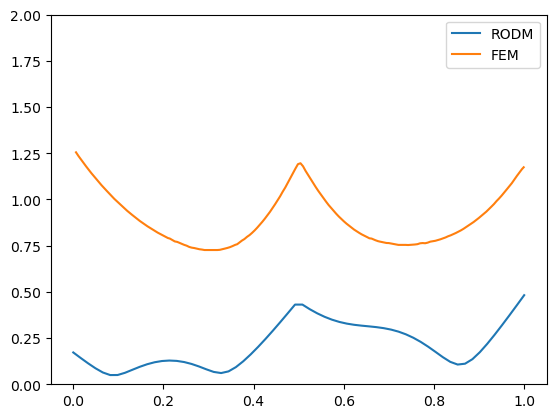

In [15]:
import matplotlib.pyplot as plt
# mid = displacement_old[(367+6)*6-6:(427+7)*6-6,:]
heave = abs(displacement_old[2::6])
i = 6
x = np.linspace(0, 1, 62)
www = heave[62*i + 0:62*i + 62][::-1]
plt.plot(x,www)
import pandas as pd
df = pd.read_csv(r'E:\phd\Code\DM-FEM2D\FEM_Reduce\Hinge\Default Dataset.csv')
plt.plot(df.iloc[:, 0],df.iloc[:, 1])
plt.ylim(0,2)
plt.legend(['RODM','FEM'])

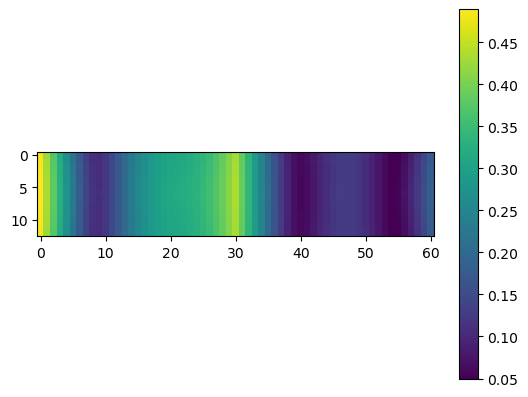

In [16]:
model1 = heave[0:403].reshape(13,31)
model2 = heave[403:806].reshape(13,31)
combined_model = np.hstack((model1, model2))
modified_model = np.delete(combined_model, 30, axis=1)
plt.imshow(modified_model)
plt.colorbar()

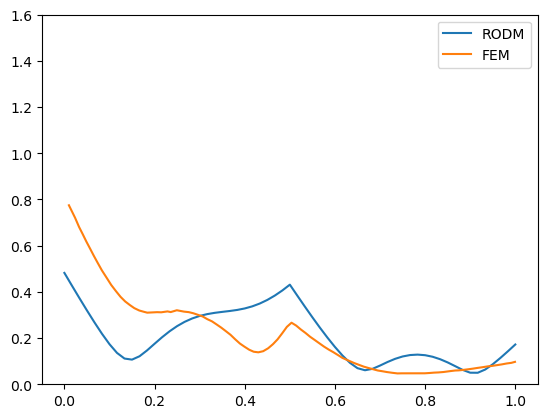

In [17]:
x = np.linspace(0, 1, 61)
plt.plot(x,modified_model[12,:])
import pandas as pd
df = pd.read_csv(r'E:\phd\Code\DM-FEM2D\FEM_Reduce\Hinge\Fu2007-120.csv')
plt.plot(df.iloc[:, 0],df.iloc[:, 1])
plt.ylim(0,1.6)
plt.legend(['RODM','FEM'])

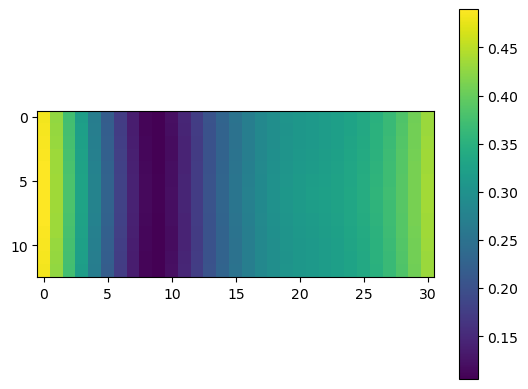

In [18]:
plt.imshow(heave[0:403].reshape(13,31))
plt.colorbar()